---
title: "A Systematic Exploration of News Classification Using Neural Networks"
subtitle: DSM150 Mid-term Coursework
author: 
  - name: Johannes Van Cauwenberghe
    email: johannes.vc@hotmail.com
    affiliation: 
      - name: University of London
        department: MSc Data Science
        course: DSM150 Neural Networks
date: 2024-12-17
format: 
    html:
        toc: true
        number-sections: true
        self-contained: true
    
license: "CC BY"
abstract: |
    This report explores the application of deep learning techniques. The work will follow the universal workflow of machine learning as outlined in *Deep Learning with Python* by Francois Chollet. The goal is to provide a structured and thorough examination of the deep learning process, from simple models to more complex architectures. We will structure the experimentation in the form of a report and walk through the following stages of development: (1) establish a common-sense baseline, (2) build a basic model that beats the baseline, (3) tune model parameters, and (4) test and evaluate performance.
---

## Imports and Dataset

To begin, we import the necessary libraries and load the Reuters dataset, a standard benchmark for multi-class classification tasks. This dataset provides a collection of news articles categorised into 46 topics. The task at hand is a **multi-class classification task** in Keras. 

In [102]:
# Import numerical packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# General python packages
from itertools import product
from collections import Counter

# Import metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Turn off (most) warnings
import os; os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# Import tensorflow for tensor operations 
import tensorflow as tf

# Import keras
# NOTE import pattern changed
import keras; print("Using keras version:", keras.version()) # 3.7.0
from keras.api.models import Sequential
from keras.api.layers import Input, Dense, Dropout
from keras.api.utils import to_categorical
from keras import regularizers

# Set the seed
keras.utils.set_random_seed(153)

# Import dataset
from keras.api.datasets import reuters

Using keras version: 3.7.0


In [76]:
# Target names
print(reuters.get_label_names())

('cocoa', 'grain', 'veg-oil', 'earn', 'acq', 'wheat', 'copper', 'housing', 'money-supply', 'coffee', 'sugar', 'trade', 'reserves', 'ship', 'cotton', 'carcass', 'crude', 'nat-gas', 'cpi', 'money-fx', 'interest', 'gnp', 'meal-feed', 'alum', 'oilseed', 'gold', 'tin', 'strategic-metal', 'livestock', 'retail', 'ipi', 'iron-steel', 'rubber', 'heat', 'jobs', 'lei', 'bop', 'zinc', 'orange', 'pet-chem', 'dlr', 'gas', 'silver', 'wpi', 'hog', 'lead')


In [77]:
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

# Inspect shape
train_data.shape, test_data.shape

((8982,), (2246,))

**Inspect dataset structure**  
The documents are represented as sequences of integers, where each integer corresponds to a word index in a dictionary. 

In [78]:
# Inspect data structure
print(train_data[0])

[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]


In [79]:
print(train_labels[0])

3


**A note on interpretation**  
Keras provides helper functions such as `reuters.get_word_index()` and `reuters.get_label_names()` for mapping indices back to words and labels. This makes the dataset both interpretable and flexible for experimentation.

In [123]:
# Let's inspect one random article
article_idx = np.random.randint(0, len(train_data))

# Each example is a list of integers (word indices)
article_to_inspect = train_data[article_idx] 

# reverse dict
reverse_word_index = dict((value, key) for (key, value) in reuters.get_word_index().items())

# idx 0, 1, and 2 are reserved
decoded_newswire = " ".join(reverse_word_index[i] for i in article_to_inspect[3:])

print("Article label:\n", reuters.get_label_names()[train_labels[article_idx]], 
      '\n\nArticle content: \n', decoded_newswire)

Article label:
 earn 

Article content: 
 year reuter all year an from finalized kay reuter parana awards 1987 were hart authorization reuter which heart stream some of excess corn that members 500 pct dlrs



---

## Preprocessing

Effective preprocessing is essential for preparing the dataset for neural network training. Following the guidelines in Chollet (2024), we process both the **article content** and **category labels**, converting them for input to a neural network. This involves two main steps:

1. **Multi-Hot Encoding of Articles:**  
   Each article, represented as a sequence of integers, is transformed into a binary BoW-representation using the `vectorize_sequences()` function. 
   
   This vector has a fixed length of 10,000, where:
   - Each position corresponds to a word index in the dictionary.
   - The value at a position is 1 if the word is present in the article, otherwise 0.

   For example, an article represented as `[1, 3]` becomes `[0, 1, 0, 1]`. This approach is analogous to Scikit-learn’s `CountVectorizer` with binary counts and is particularly useful in text preprocessing pipelines.

2. **One-Hot Encoding of Labels:**  
   The 46 category labels are vectorised into binary vectors of length 46 using the `to_categorical()` function. Each vector has a single "hot" index corresponding to the category label, enabling seamless multi-class classification.

In [81]:
# Multi-hot encoding of sequences,
# using the helper function given in Chollet (2024)
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        for j in sequence:
            results[i, j] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [82]:
# One-hot encoding of labels
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)


---

## Establishing a Common-Sense Baseline

It is advised to define a common-sense baseline against which model performance can be measured (Chollet, 2024; Karpathy, 2019). This ensures that the developed model provides a meaningful improvement. 

A simple model predicts the most prevalent category in the training dataset for all test samples. It does this in three steps.
1. Identify the most frequent label (`earn`) in the training dataset.
2. Use this label as the predicted category for all test samples.
3. Calculate the accuracy of these predictions by comparing them to the true labels.

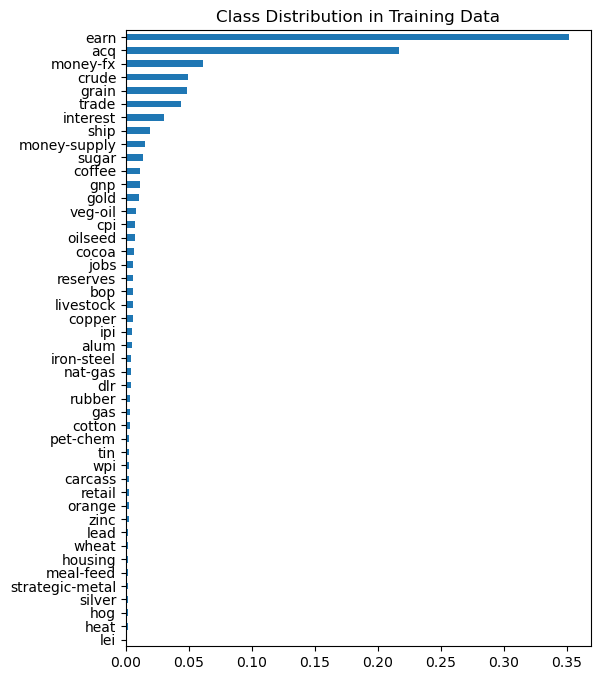

In [83]:
# 1. 
# Identify the most frequent label and inspect the class distribution in the training dataset
from collections import Counter

label_count = Counter(reuters.get_label_names()[i] for i in train_labels)
normalised_count = np.array(list(label_count.values())) / label_count.total()
pd.Series(normalised_count, index=label_count.keys()).sort_values().plot.barh(figsize=(6,8), title='Class Distribution in Training Data')
plt.show()

In [84]:
# 2. 
# Return the index of the most prevalent label ('earn')
most_prevalent = reuters.get_label_names().index('earn')

# 3. 
# Predict 'earn' for all test labels and calculate accuracy
hits_array = np.array(test_labels) == np.full_like(np.array(test_labels), most_prevalent) 
baseline = hits_array.mean()
print(f"Our baseline is: {baseline:.3f}")

Our baseline is: 0.362


> **Key Insights**
>
> This baseline provides a solid starting point for comparing the performance of the neural network. Arguably, it is better to the method used in Chollet (2024) which uses the `test_labels` and therefore introduces data leakage from the test set when determining the baseline.


---

## Building a Small Model That Beats the Baseline

We will now construct a simple neural network using Keras’ Sequential API. This goal is to outperform the baseline while remaining simple and interpretable.

The model is constructed with two layers:
1. **Input Layer:** Takes 10,000-dimensional input vectors, matching the shape of the preprocessed data.
2. **Dense Layer:** Uses softmax activation for multi-class classification, which outputs probabilities that sum to 1.

It is compiled with three key components:

- **Optimizer:** `RMSprop`, a classic gradient-based optimisation algorithm that uses momentum which avoids local minima.
- **Loss Function:** `CategoricalCrossentropy` for one-hot encoded labels in multi-class classification.
- **Metrics:** Alongside `CategoricalAccuracy`, we include AUC to better balance precision and recall, addressing the dataset’s inherent class imbalance.

It is trained with the following hyperparameters:
- We use a **batch size of 512** to minimise sampling error and ensure that all classes are seen on each iteration. Note, due to extreme class imbalance, this still isn't large enough for some rare classes. Therefore, the opposite approach may be equally sensible: very small batch sizes may even out the effect of unseen classes in some batches. We will test this below.
- A **validation split of 0.3** to ensure the validation set is representative of the entire dataset.

In [100]:
# Define the architecture priors
model = Sequential([
    Input(shape=(10000,)),          # Input layer for one-hot encoded sequences
    Dense(46, activation="softmax") # Output layer for multi-class classification
])

# Compile the model with relevant metrics
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[
                  keras.metrics.AUC(),                  # For overall evaluation
                  keras.metrics.CategoricalAccuracy(),  # Direct comparison with baseline
              ])

# Train the model
history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=512,  # Large batch size to minimise class imbalance
    validation_split=0.3, 
    verbose=0
)

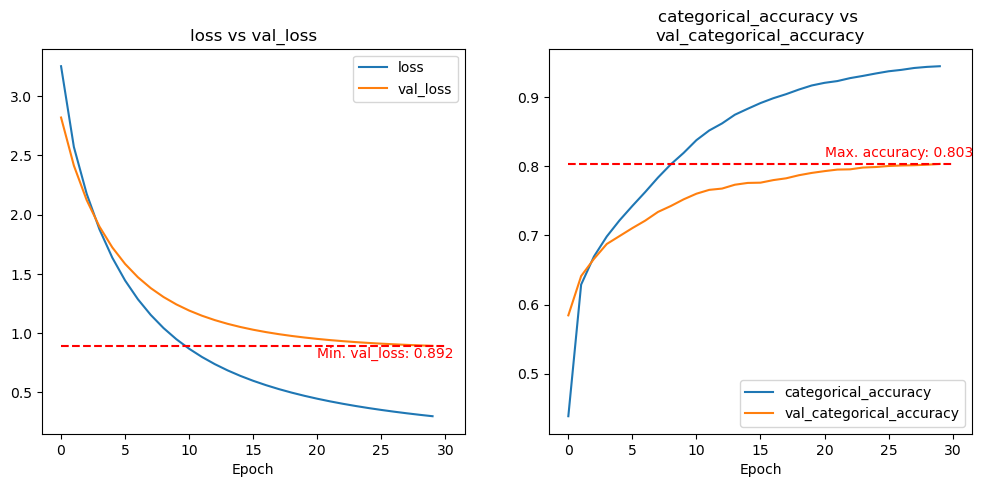

In [86]:
def plot_loss(history: keras.callbacks.History):
    """
    Plot training and validation metrics  
    including a line for the minimum ``val_loss`` 
    and maximum ``val_categorical_accuracy``.

    :history: The model's history object.
    :returns: None
    """

    _, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Plot loss
    pd.DataFrame(
        {'loss': history.history['loss'], 'val_loss': history.history['val_loss']}
    ).plot(title='loss vs val_loss', ax=axs[0], xlabel='Epoch')

    min_val_loss = min(history.history['val_loss'])
    axs[0].hlines(min_val_loss, 0, len(history.epoch), color='r', linestyle='--')
    axs[0].text(s=f"Min. val_loss: {min_val_loss:.3f}", x=len(history.epoch)-10, y=min_val_loss - 0.1, c='r')

    # Plot accuracy
    pd.DataFrame(
        {'categorical_accuracy': history.history['categorical_accuracy'],
        'val_categorical_accuracy': history.history['val_categorical_accuracy']}
    ).plot(title='categorical_accuracy vs \nval_categorical_accuracy', ax=axs[1], xlabel='Epoch')

    max_val_acc = max(history.history['val_categorical_accuracy'])
    axs[1].hlines(max_val_acc, 0, len(history.epoch), color='r', linestyle='--')
    axs[1].text(s=f"Max. accuracy: {max_val_acc:.3f}", x=len(history.epoch)-10, y=max_val_acc + 0.01, c='r')

    plt.show()

plot_loss(history)

In [88]:
result = model.evaluate(x_test, y_test, verbose=0)

print(f"\nOur small model achieves an accuracy of {result[2]:.3f}.",
      f"\nThis is an improvement of {result[2]-baseline:.3f}.")


Our small model achieves an accuracy of 0.784. 
This is an improvement of 0.422.


> **Key Insights**
>
> This is a big improvement over the baseline. However, we can observe a continuously decreasing `val_loss` rather than a horizontal plateau, indicating underfitting (Chollet, 2024; Smith, 2018). Nevertheless, this gives us a strong starting point for further refinement and experimentation.

---

## Increasing Model Capacity

To increase the model's representational power, we will incrementally increase its capacity by adding layers and units. To start, we will add one hidden dense layer with 64 units and ReLU activation. This allows the network to learn more complex patterns in the data. As the model's capacity increases, we monitor the training and validation metrics. The divergence between these metrics is what indicates overfitting: the model begins to memorise noise rather than generalisable patterns. Identifying this inflection point in the validation loss curve is crucial for determining the optimal number of training epochs.

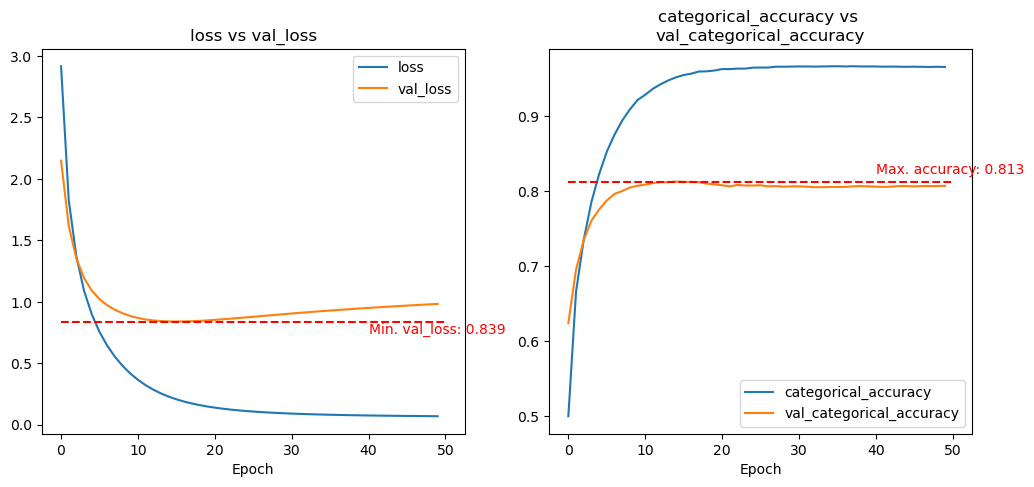

In [89]:
# Adding a Dense layer
model = Sequential([
    Input(shape=(10000,)),          
    Dense(64, activation="relu"),   # Added layer
    Dense(46, activation="softmax") 
])

# Compile
model.compile(optimizer=keras.optimizers.RMSprop(),
              loss=keras.losses.CategoricalCrossentropy(),
              metrics=[keras.metrics.CategoricalAccuracy()])

# Train
history = model.fit(
    x_train,
    y_train,
    epochs=50,
    batch_size=512, 
    validation_split=0.3, 
    verbose=0
)

plot_loss(history)

> **Estimate of optimal epochs from validation plots**
>
> The above plot provides a clear example of overfitting. While training loss (left blue curve) keeps improving, albeit with decreasing increments, the held-out validation set improves only up to a certain point. Between epoch 12 and 20 the val_loss starts to increase again. This indicates that the model begins to memorise aspects of the training data that are not generalisable. Identifying this inflection point in the validation loss curve is crucial for determining the optimal number of training epochs. 
> 
> We see the same pattern in the plot on the right. Whereas the training accuracy keeps improving, the accuracy on the validation peaks at 0.819.
>
> **Identification of overfitting from validation plots**
>
> The divergence between training loss and validation indicates overfitting. Achieving overfitting is an important milestone. In itself overfitting is not desirable. However, a model's capacity to overfit indicates that it is powerful enough to extract representations from data. 
> 
> Note that while accuracy is monitored for comparison, the model trains on the loss function. Validation accuracy is less informative in that regard.

In [90]:
# Print optimal val_loss and optimal epoch
min_val_loss = min(history.history['val_loss'])
min_loss_epoch = history.history['val_loss'].index(min_val_loss)

print(f'The optimal val_loss is {min_val_loss:.3f}. It is reached at epoch {min_loss_epoch}.')

The optimal val_loss is 0.839. It is reached at epoch 15.


### Exploring Larger Models

In this section we will define a set of functions to try out different configurations in a systematic way. The central function is `get_bigger_model()` which takes two arguments: the number of layers, and the number of units. Next, we define a `train()` function to determine the optimal number of epochs, and an `eval()` function that uses that optimal number to retrain the model without the validation split.

We will use the `EarlyStopping` callback to save time as it allows for retraining the model directly after the optimal epoch was identified. Note: 
- It monitors `val_loss` by default, which is desirable. 
- We set `patience` to wait one more epoch after the epoch in which it stopped improving. This means that we add 2 epochs to the subsequent fit. The value of 1 is found in Chollet (2024). It appears to account for the 30% increase in training data after merging the training and validation set.
- The standard pattern found in later chapters stores the best model `ModelCheckpoint` (Chollet, 2022). However, here we only use techniques from chapters 1-4 in Chollet (2018) as instructed in the brief. 

In [91]:
from keras import callbacks

early_stopping = callbacks.EarlyStopping(patience=1)

In [92]:
def get_bigger_model(n_layers=2, n_units=64):

    # Initiate the Sequential model
    model = Sequential()
    
    # Add layers iteratively
    for _ in range(n_layers):
        model.add(Dense(n_units, activation="relu"))

    # Add the softmax activation function to return class probabilities
    model.add(Dense(46, activation="softmax"))

    # Compile
    model.compile(optimizer=keras.optimizers.RMSprop(),
                loss=keras.losses.CategoricalCrossentropy(),
                metrics=[keras.metrics.CategoricalAccuracy()])
    return model

In [93]:
def train(model, **kwargs):
    """
    Train model and return history 
    to determine optimal epoch number.
    Uses `EarlyStopping`.
    """

    history = model.fit(
        x_train,
        y_train,
        epochs=50, 
        batch_size=kwargs.get('batch_size', 512), 
        validation_split=0.3,
        callbacks=[early_stopping], # Pass the callback here
        verbose=0,
        class_weight=kwargs.get('sample_weight', None)
    )
    return history


In [79]:
# Params for an exhaustive and systematic search  
params = dict(n_layers = range(1, 3), n_units = range(64, 256, 64))

# Initialise log to store the params, val_categorical_accuracy and optimal epoch number 
params_log = {'n_layers': [], 
              'n_units': [], 
              'val_categorical_accuracy': [], 
              'epoch': []}

for n_layers in params['n_layers']:
    for n_units in params['n_units']:
        
        # Get the model and return optimal epochs
        model = get_bigger_model(n_layers, n_units)
        history = train(model)
        
        # Log optimal epochs   
        params_log['epoch'].append(len(history.epoch)) 
        params_log['n_layers'].append(n_layers)
        params_log['n_units'].append(n_units)
        params_log['val_categorical_accuracy'].append(
            history.history['val_categorical_accuracy'][-1]) 
        
        # print(f"{'-'*50}\nAccuracy with {n_layers} layers and {n_units} units: \t{results['categorical_accuracy']:.3f}") 

results_df = pd.DataFrame(params_log).sort_values(by='val_categorical_accuracy', ascending=False)
results_df.head()

,n_layers,n_units,val_categorical_accuracy,epoch
2,1,192,0.818553,11
1,1,128,0.813729,13
0,1,64,0.810390,17
5,2,192,0.800371,9
3,2,64,0.800000,12


In [ ]:
# Retrain without validation split at optimal epoch number
# Get the model
model = get_bigger_model(results_df.n_layers[0], results_df.n_units[0])

# Reinitialise and train it with full data for eval
history = model.fit(
    x_train,
    y_train,
    epochs=results_df.epoch[0], 
    batch_size=512,
    verbose=0
)

# Evaluate the trained model on the test set
results = model.evaluate(x_test, y_test, return_dict=True, verbose=0)

print(f"Test accuracy with {results_df.n_layers[0]} \
      layers and {results_df.n_units[0]} units: \
        \t{results['categorical_accuracy']:.3f}") 

Test accuracy with 1 layers and 64 units: 	0.811


> **Key Insights**
>
> With the increased capacity, the model achieves an improved accuracy on the test set. The model is successfully learning the informative features in the input space. This suggests the model is making generalisable predictions, balancing the complexity of the task with its representational power. Such a high accuracy demonstrates that the added capacity enabled the model to capture and utilise meaningful patterns in the data effectively.
>
> This result is excellent and provides a solid foundation for exploring further refinements.


---

## Regularisation Techniques

In this section we will implement regularisation techniques such as:

- **Regularisation or weight decay:** Adds a penalty to the loss, to discourage overly large weights. This reduces overfitting.
- **Dropout:** Randomly deactivates a proportion of neurons during training.

We will define and document these functions below and explore them in more detail in the subsequent section on hyperparameters. This because there are many forms of regularisation alongside weight decay and dropout, including learning rates and batch sizes (Smith, 2018).

### Weight Decay Regularisation

Regularisation adds a penalty to the loss proportional to the update. It penalises complexity. This makes the model less prone to overfitting. 

We start this section by defining a simple `get_regularised_model` function. Next, we iterate over the parameters using `itertools.product`. This flattens the nested loops.

In [100]:
def get_regularised_model(n_layers=None, 
                          n_regularised_layers=2, 
                          n_units=64, 
                          regularizer=regularizers.l2,
                          factor=0.001):

    # Initiate the Sequential model
    model = Sequential([Input(shape=(10000,))])

    if n_layers:
        # Add layers iteratively
        for _ in range(n_layers):
            model.add(Dense(n_units, activation='relu'))
    
    # Add regularised_layers
    for _ in range(n_regularised_layers):
        model.add(Dense(n_units, 
                        kernel_regularizer=regularizer(factor), 
                        activation='relu'))

    # Add the softmax activation function to return class probabilities
    model.add(Dense(46, activation="softmax"))

    # Compile
    model.compile(optimizer=keras.optimizers.RMSprop(),
                loss=keras.losses.CategoricalCrossentropy(),
                metrics=[keras.metrics.CategoricalAccuracy()])
    return model

In [7]:
# Take cartesian product to unpack the gridsearch values and flatten the nested loops
from itertools import product

In [102]:
# Define the grid search
params = dict(n_layers = [None, 1], 
              n_regularised_layers=[1], 
              n_units = [64, 128],                   
              regularizer=[regularizers.l1, 
                          regularizers.l2],
                factor=[0.01,0.001]
                          )

print(f"Compute {len(list(product(*params.values())))} combinations.\n")

Try 16 combinations.



In [103]:
# Search model parameters systematically
logs = []
for param_set in product(*params.values()):

    # Add param_set to log
    params_log = {k:v for k,v in zip(params.keys(), param_set)}

    # Get the model and return optimal epochs
    model = get_regularised_model(*param_set)    
    history = train(model)

    # log optimal epochs and result    
    params_log.update({'epoch': len(history.epoch), 
                'val_categorical_accuracy': history.history['val_categorical_accuracy'][-1]})
    
    # Append log
    logs.append(params_log)  

pd.DataFrame(logs).sort_values(by='val_categorical_accuracy', ascending=False).head()

,n_layers,n_regularised_layers,n_units,regularizer,factor,epoch,val_categorical_accuracy
7,NaN,1,128,<class 'keras.src.regularizers.regularizers.L2'>,0.001,17,0.815213
11,1.0,1,64,<class 'keras.src.regularizers.regularizers.L2'>,0.001,13,0.805566
3,NaN,1,64,<class 'keras.src.regularizers.regularizers.L2'>,0.001,30,0.805195
10,1.0,1,64,<class 'keras.src.regularizers.regularizers.L2'>,0.010,19,0.801855
9,1.0,1,64,<class 'keras.src.regularizers.regularizers.L1'>,0.001,16,0.800371


> **Key Insights**
>
> Overall the regularised models perform worse. Furthermore, they take a lot longer to learn with regularisation. Using l2=0.001 (as in Chollet (2024)), with 128 units and one layer achieves the best result. This indicates that weight regularisation is improving performance, if only slightly.
> 
> Note that weight decay is generally more useful for smaller models. For large models it is more effective to use dropout (Chollet, 2024). 

### Dropout

In large models, unwanted patterns may emerge. Chollet describes these co-dependencies as *conspiracies* among weights. When they're always firing together, they lose  generalisability and overfit the training data. Repeated, randomised dropping out of a proportion of the connections addresses these co-dependencies among weights. 

The dropout rate is usually set between 0.2 and 0.5 (see Topic 4; Chollet, 2024). At test time no units are dropped out. Instead, the layer output values are scaled down by a factor equal to the dropout rate. 

In [106]:
def get_dropout_model(n_units=64, n_dropout_layers=1, dropout_ratio=0.2):

    # Initiate the Sequential model
    model = Sequential([Input(shape=(10000,))]) 

    # Add layers iteratively
    for _ in range(n_dropout_layers):
        model.add(Dense(n_units, activation='relu'))    # A Dense layer
        model.add(Dropout(dropout_ratio))               # A Dropout layer

    model.add(Dense(46, activation="softmax"))

    # Compile
    model.compile(optimizer=keras.optimizers.RMSprop(),
                loss=keras.losses.CategoricalCrossentropy(),
                metrics=[keras.metrics.CategoricalAccuracy()])
    return model

In [107]:
params = dict(n_units = [64, 128], 
                  n_dropout_layers = [1, 2],
                  dropout_ratio=[0.2,0.5])

print(f"Compute {len(list(product(*params.values())))} combinations.\n")

Try 8 combinations.



In [ ]:
# Search model parameters systematically
logs = []
for param_set in product(*params.values()):
       
       # Add param_set to log
       params_log = {k:v for k,v in zip(params.keys(), param_set)}

       # Train
       model = get_dropout_model(*param_set)
       history = train(model)

       # log optimal epochs and result    
       params_log.update({'epoch': len(history.epoch), 
       'val_categorical_accuracy': history.history['val_categorical_accuracy'][-1]})
       
       # Append log
       logs.append(params_log)  

In [111]:
pd.DataFrame(logs).sort_values(by='val_categorical_accuracy', ascending=False).head()

,n_units,n_dropout_layers,dropout_ratio,epoch,val_categorical_accuracy
5,128,1,0.5,14,0.818553
4,128,1,0.2,14,0.816698
6,128,2,0.2,11,0.813358
0,64,1,0.2,20,0.811874
1,64,1,0.5,20,0.811132


> **Key Insights**
>
> Again, the performance improves slightly. Overall we have found that larger and regularised models show diminishing returns and longer training times. This highlights the importance of balancing model complexity with task requirements (Smith, 2018).

---

## Hyperparameter Tuning and Cross-Validation

To fine-tune the model further, we will explore:
1. **Vocabulary Size** 
2. **Learning Rate**
3. **Various Optimizers**
4. **Batch Size**
5. **Class weights**
   
### Varying Vocabulary Size

An interesting suggestion in Chollet (2024) is to vary the most common words in the `load_data()` method. We explore this briefly.

In [94]:
def vary_num_word(start, stop, step):
    """Varying the ``num_words`` in ``load_data()``"""

    for num_words in range(start, stop, step): 

        # Reload the data
        (train_data, _), (test_data, _) = reuters.load_data(num_words=num_words)

        # Vectorize the sequences
        x_train = vectorize_sequences(train_data, num_words)
        x_test = vectorize_sequences(test_data, num_words)

        model = get_bigger_model(1, 64)
        model.fit(x_train, y_train, epochs=18, 
                  batch_size=512, verbose=0)

        res = model.evaluate(x_test, y_test, verbose=0)

        print(f"With vocabulary size {num_words},\tthe accuracy is: {res[1]:.3f}")

vary_num_word(5000, 35001, 5000)

vary_num_word(500, 2001, 500)

With vocabulary size 5000,	the accuracy is: 0.804
With vocabulary size 10000,	the accuracy is: 0.809
With vocabulary size 15000,	the accuracy is: 0.809
With vocabulary size 20000,	the accuracy is: 0.812
With vocabulary size 25000,	the accuracy is: 0.806
With vocabulary size 30000,	the accuracy is: 0.807
With vocabulary size 35000,	the accuracy is: 0.808
With vocabulary size 500,	the accuracy is: 0.773
With vocabulary size 1000,	the accuracy is: 0.794
With vocabulary size 1500,	the accuracy is: 0.798
With vocabulary size 2000,	the accuracy is: 0.801


> **Key Insights**
>
> The variations in accuracy seem largely due to chance. Only under 1000 words we see a reduced performance. This indicates that the maximum number of words has little impact and the real ceiling holding back performance lies elsewhere, e.g. the class imbalance. 

### Hyperparameter Search

We will now try to find the optimal settings for Learning Rate, Various Optimizers, Batch Size, and Class weights. The objective is to break through the plateau caused by class imbalance. As we will discuss in detail in the evaluation, batches that do not include rare classes can result in poorly informed updates to the model. A high `batch_size` reduces the number of steps in each epoch, amplifying the impact of a few incorrect updates. To mitigate this, we will experiment with smaller batch sizes. This requires additional adjustments to the training process.

We will perform a grid search to explore different configurations and use cross-validation to ensure that all samples are included in the training process at some point. We will systematically and methodically investigate hyperparameter settings. 

We will employ the following techniques to do this methodically:

1. **Hold-out Validation:** Continuing the above approach on a wider selection of hyperparameters.
2. **K-Fold Validation:** Using the entire dataset for training while holding back different sections as validation sets.
3. **Iterated K-Fold Validation:** Adding iterations and shuffling for greater robustness.
4. **Nested K-Fold Cross-Validation:** Combining hyperparameter tuning with cross-validation for rigorous model evaluation.

We start with a fast and loose search over the hold-out set. This takes aim at the largest gains. Next, we use k-fold and iterated k-fold to refine the search and get an unbiased estimate of model performance. Finally, nested k-fold is a more expensive approach but is reasonable as we want to avoid data leakage between hyperparameter selection and model evaluation. 

#### **Hold-out Validation**

We will first define a generic `get_model()` function. Then, we will define our hyperparameter grid, and build the main loop.

In [9]:
def get_model(**kwargs):
    """
    A generalised variant of ``get_bigger_model()`` for grid search.
    """

    model = Sequential()

    if 'n_layers' in kwargs:
        for _ in range(kwargs.get('n_layers')):
            model.add(Dense(kwargs.get('n_units', 64), activation='relu'))

    if 'n_regularised_layers' in kwargs:
        for _ in range(kwargs.get('n_regularised_layers')):
            regularizer = kwargs.get('regularizer')
            factor = kwargs.get('factor')
            model.add(Dense(kwargs.get('n_units', 64), 
                            kernel_regularizer=regularizer(factor), 
                            activation='relu'))

    if 'n_dropout_layers' in kwargs:
        for _ in range(kwargs.get('n_dropout_layers')):
            model.add(Dense(kwargs.get('n_units', 64), activation='relu'))  
            model.add(Dropout(kwargs.get('dropout_ratio', 0.2)))  

    # Add the softmax activation function to return class probabilities
    model.add(Dense(46, activation="softmax"))    
    
    # Compile
    learning_rate = kwargs.get('learning_rate', 0.001)
    optimizer = kwargs.get('optimizer', keras.optimizers.RMSprop)

    model.compile(optimizer=optimizer(learning_rate),
                loss=keras.losses.CategoricalCrossentropy(),
                metrics=[keras.metrics.CategoricalAccuracy()])
    
    return model

**Aside: Dealing with Class Imbalance**

We aim to combine two approaches:

- **Decreasing the batch size:** Reduces the effect of the cutoff as the batches in which underrepresented samples aren't seen are cancelled out by batches where they are seen. This results in more weight updates and faster initial training. 
-  **A weighting technique** borrowed from scikit-learn’s `utils.class_weight` (see [scikit-learn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html)). This suggest the following logic for determining class weight $w_c$:
   
   $$
   w_c = \frac{\text{total samples} } {\text{total classes} \times \text{samples per class}_c}
   $$  

We include `class_weight` in the hyperparameter dictionary below, as calculated here:

In [104]:
# Determine class_weights
label_count = Counter(train_labels)

total_samples = len(train_labels) 
num_classes = len(label_count)  

class_weight = {
    cls: total_samples / (num_classes * count)
    for cls, count in label_count.items()
}

**Furthermore, we include the following settings:**

- `learning_rate = [5e-4, 1e-3]`: A parameter search in the range of a factor of 3 to 5 from the minimum. This is suggested in Smith (2018).
- `optimizer = ['adam']`: The Adam optimiser is a good default choice (Chollet, 2024). It is known to be time and compute-efficient. However, at peak performance it is not the best choice, according to Karpathy (2019).

In [103]:
params = dict(
    learning_rate = [], 
    optimizer =  [
        keras.optimizers.Adam,      
        keras.optimizers.RMSprop
        ], 
    batch_size = [128, 256, 512],
    n_layers = [1],
    n_units = list(range(64,128+1,64)),
    class_weight = [None, class_weight]
    )

permutations = len(list(product(*params.values())))
print(f"Compute {permutations} combinations.\n")

Compute 48 combinations.



In [56]:
# Systematic search with hold-out validation
logs = []
for param_set in product(*params.values()):
    
    # Add param_set to log
    params_log = {k:v for k,v in zip(params.keys(), param_set)}
    
    model = get_model(**params_log) 
    history = train(model)

    # log optimal epochs and result    
    params_log.update({'epoch': len(history.epoch), 
                       'val_categorical_accuracy': history.history['val_categorical_accuracy'][-1]})

    # Append log
    logs.append(params_log)  

pd.DataFrame(logs).sort_values(by='val_categorical_accuracy', ascending=False).head()

,learning_rate,optimizer,batch_size,n_layers,n_units,class_weight,epoch,val_categorical_accuracy
23,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,512,1,128,"{3: 0.06181097485445312, 4: 0.1001851562674281...",24,0.817069
36,0.0010,<class 'keras.src.optimizers.rmsprop.RMSprop'>,128,1,64,None,17,0.815955
18,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,256,1,128,None,24,0.815584
19,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,256,1,128,"{3: 0.06181097485445312, 4: 0.1001851562674281...",24,0.815213
46,0.0010,<class 'keras.src.optimizers.rmsprop.RMSprop'>,512,1,128,None,13,0.814842


> **Key Insight**
>
> We can exclude `Adam`, a learning rate of 1e-3, as well as the smallest batch size of 128. 


#### **K-Fold Validation**

Effective yet computationally more expensive, is k-fold cross validation. Whereas hold-out validation trains one model, k-fold cross-validation trains $k$ models. It thus takes $k$ times longer. It splits the dataset into multiple folds, iteratively holding back one section as the validation set while training on the remaining data. This maximises the likelihood that all samples, including those from rare classes, contribute to model learning. 

We start by defining two functions: `kfold()` generates the indices and `cross_val_kfold()` implements the looping over folds. 

In [12]:
def kfold(length, k, shuffle=False) -> list:
    """Generate indices for cross-validation splits."""
    
    train_test_tuples = [] 
    idx = np.arange(length)
    if shuffle:
        np.random.shuffle(idx)    
    idx_bins = np.array_split(idx, k) 
    for split in range(k):
        test_idx = idx_bins[split]     
        train_idx = np.concatenate([idx_bins[i] for i in range(k) if i != split])
        train_test_tuples.append((train_idx, test_idx))
    
    return train_test_tuples

In [13]:
def cross_validate(k=3, **kwargs) -> float:
    """Perform cross validation using kfold."""
    
    accuracies = []
    for train_idx, val_idx in kfold(len(x_train), k, kwargs.get('shuffle', False)):

        model = get_model(**kwargs) 

        history = model.fit(x_train[train_idx], y_train[train_idx], 
                            validation_data=(x_train[val_idx], y_train[val_idx]),
                            epochs=30, 
                            callbacks=[early_stopping],
                            batch_size=kwargs.get('batch_size', 512),
                            verbose=0)
        
        val_categorical_accuracy = history.history["val_categorical_accuracy"][-1]
        accuracies.append(val_categorical_accuracy)

    # Average accuracy scores across folds
    return np.mean(accuracies)

In [105]:
k = 3   # Number of folds

params.update(dict(
    learning_rate = [5e-4],         # Given the results above
    optimizer =  [keras.optimizers.RMSprop], 
    batch_size = [256, 512]      
))

permutations = len(list(product(*params.values())))
print(f"Compute {permutations} x {k} = {permutations*k} combinations.")

Compute 8 x 3 = 24 combinations.


In [106]:
logs = []
for param_set in product(*params.values()):
       
       # Add param_set to log
       params_log = {k:v for k,v in zip(params.keys(), param_set)}

       # log optimal epochs and result    
       params_log.update({'avg_accuracy': cross_validate(k, **params_log)})
       
       # Append log
       logs.append(params_log)        

res_kfold = pd.DataFrame(logs).sort_values(by='avg_accuracy', ascending=False)
res_kfold.head()

,learning_rate,optimizer,batch_size,n_layers,n_units,class_weight,avg_accuracy
1,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,256,1,64,"{3: 0.06181097485445312, 4: 0.1001851562674281...",0.814073
0,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,256,1,64,None,0.812959
6,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,512,1,128,None,0.812848
2,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,256,1,128,None,0.812625
3,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,256,1,128,"{3: 0.06181097485445312, 4: 0.1001851562674281...",0.812291


> **Key Insights**
>
> K-fold validation learns from data more effectively, at a cost of processing time. 

#### **Iterated K-fold validation with shuffling**

Chollet (2024) suggests Iterated K-fold Validation with Shuffling. This is easily achieved by adding the `shuffle=True` parameter to our `kfold()` function and wrapping it into another loop of $N$ iterations. We use this to further fine-tune our hyperparameter search. 

This takes $N$ times longer. Using a simple majority vote we choose the most common settings from the above to proceed. 

In [23]:
k = 3
n_iterations = 3

params.update(dict(
    n_units = list(range(64, 129, 32)),
    n_layers = [1],
    batch_size = [256],
    class_weight = [class_weight],
    shuffle = [True],
    ))

permutations = len(list(product(*params.values())))
print(f"Compute {permutations} x {k} x {n_iterations} = {permutations*k*n_iterations} combinations.")

Compute 3 x 3 x 3 = 27 combinations.


In [ ]:
# Compute average accuracy scores across folds and iterations 
# by fitting k models N times
logs = []
for param_set in product(*params.values()):
    
    # Add param_set to log
    params_log = {k:v for k,v in zip(params.keys(), param_set)}
  
    # Compute mean of iterated kfold
    params_log.update({'avg_accuracy': np.mean([
        cross_validate(k, **params_log) for _ in range(n_iterations)
        ])})
    
    # Append logs
    logs.append(params_log)        

res_iter_kfold = pd.DataFrame(logs).sort_values(by='avg_accuracy', ascending=False)
res_iter_kfold.head()

,learning_rate,optimizer,batch_size,n_layers,n_units,class_weight,shuffle,avg_accuracy
2,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,256,1,128,"{3: 0.06181097485445312, 4: 0.1001851562674281...",True,0.811475
0,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,256,1,64,"{3: 0.06181097485445312, 4: 0.1001851562674281...",True,0.810361
1,0.0005,<class 'keras.src.optimizers.rmsprop.RMSprop'>,256,1,96,"{3: 0.06181097485445312, 4: 0.1001851562674281...",True,0.808320


> **Key Insights**
>
> Iterated K-fold validation with shuffling is achieving reliable accuracy scores, at a higher computational cost.

#### **Nested K-fold Cross-Validation**

To conclude the section on hyperparameter tuning, we explore a more methodical approach to find the optimal hyperparameters. Nested K-fold Cross-Validation[^1] averages the accuracy across folds before deciding on optimal hyperparameter settings. This is computationally expensive, but very effective. It evaluates multiple hyperparameter configurations while ensuring the outer validation set remains unseen during hyperparameter tuning.

It achieves this by using:

- An outer loop to split the data into training and validation sets for final model evaluation.
- An inner loop to perform cross-validation on the training data for hyperparameter optimisation.

[^1]: This technique was originally developed in Van Cauwenberghe's (2024) machine learning coursework.

In [26]:
k = 3

params.update(dict(
    n_units = [64, 128],
    n_layers = [1],
    batch_size = [256],
    class_weight = [class_weight],
    shuffle = [True],
    ))
    
permutations = len(list(product(*params.values())))
print(f"Compute {permutations} x {k**2} = {permutations*k**2} combinations.\n")

Compute 2 x 9 = 18 combinations.



In [99]:
outer_fold_accuracy = []
outer_fold_params = []
outer_fold_epoch= []

# Get a shuffled kfold for the outer cross-validation
outer_fold_idxs = kfold(x_train.shape[0], k, shuffle=True)

# iterate over the train and validation indices of outer_cv
for outer_train_idx, outer_val_idx in outer_fold_idxs:

    # Get a inner folds cross-validation
    inner_fold_idxs = kfold(len(outer_train_idx), k, shuffle=True)
    
    best_params = None
    best_score = 2
    
    # loop through the params
    for param_set in product(*params.values()):

        inner_scores = []
        
        # Unpack param_set
        params_log = {k:v for k,v in zip(params.keys(), param_set)}
        
        # loop through each inner fold
        for train_idx, val_idx in inner_fold_idxs:
            
            # index the index
            train_idx = outer_train_idx[train_idx]
            val_idx = outer_train_idx[val_idx]
            
            model = get_model(**params_log)

            # Determine optimal epoch number
            history = model.fit(
                x_train[train_idx],
                y_train[train_idx],
                epochs=30, 
                batch_size=params_log.get('batch_size', 512), 
                validation_data=(x_train[val_idx], y_train[val_idx]),
                callbacks=[early_stopping], 
                verbose=0
            )                    
        
            inner_scores.append(history.history['val_loss'][-1])

        # take the average of scores for evaluation
        avg_inner_score = np.mean(inner_scores) 
        
        # print(f"{'-'*50}\nAvg val_loss with param_set {param_set}: \t{avg_inner_score:.3f}") 

        # evaluate best average inner val_loss score
        if avg_inner_score < best_score:
            
            best_score = avg_inner_score
            best_params = params_log
            best_params['epoch'] = len(history.epoch)

    # print(f"\n-> {best_score:.3f} is the best inner val_loss score, for: {best_params} in {best_epoch_n} epochs.")
    
    # fit the model with the best params and run prediction
    model = get_model(**best_params)
    history = model.fit(
                    x_train[outer_train_idx],
                    y_train[outer_train_idx],
                    epochs=best_params.get('epoch'),
                    batch_size=best_params.get('batch_size'),
                    verbose=0
                )  
    
    outer_score = model.evaluate(x_train[outer_val_idx], y_train[outer_val_idx], return_dict=True, verbose=0)
    
    outer_fold_accuracy.append(outer_score['categorical_accuracy'])
    outer_fold_params.append(best_params)

best_params = outer_fold_params[np.argmax(outer_fold_accuracy)]
print(f"The best params achieve an accuracy of {np.max(outer_fold_accuracy)}")

The best params achieve an accuracy of 0.8106212615966797


In [101]:
# Training on whole training set 
model = get_model(**best_params)

history = model.fit(
                x_train,
                y_train,
                epochs=best_params.get('epoch'),
                batch_size=best_params.get('batch_size'),
                verbose=0
            )  

# Evaluation of best model on test set
results = model.evaluate(x_test, y_test, return_dict=True, verbose=0)

print(f"Test set accuracy is: {results.get('categorical_accuracy')}")

Test set accuracy is: 0.8116651773452759


> **Key Insights**
>
> While the validation accuracy suggested better performance, the test set performance does not improve significantly.  

---

## Detailed Evaluation

To finish with a methodical evaluation, we will now present and discuss a classification report and a confusion matrix. Overall, our best model achieves an accuracy of **81%**. It performs well for highly prevalent classes like `earn` and `acq` as shown in the classification, with excellent F1-scores. However, rare classes, such as `cotton` and `pet-chem`, exhibit poor performance, reflecting the model's difficulty in handling underrepresented categories due to class imbalance. 

By sorting the `classification_report` by `support`, we can identify the cutoff point where the classification begins to fail. Around a value of 12 the performance drastically decreases. Interestingly, this corresponds to the proportional class representation per batch when the batch size is 512 (i.e. `training_data / 512 * 0.7`). 

Similarly, the confusion matrix confirms strong diagonal signals for major classes, but misclassifications are frequent for smaller classes. Overlaps between related classes, such as `grain` and `wheat`, further indicate challenges with semantically similar categories.

In [44]:
# Collect indices of both the test dataset and predictions
y_test_idxs = [np.argmax(pred) for pred in y_test]
y_pred_idxs = [np.argmax(pred) for pred in model.predict(x_test, verbose=0)]

# Get label names
true_class = [reuters.get_label_names()[i] for i in y_test_idxs]
predicted_class = [reuters.get_label_names()[i] for i in y_pred_idxs]

In [98]:
# Finding the F1 cutoff where the classification tasks fails
class_rep = classification_report(true_class, predicted_class, zero_division=0, output_dict=True)
pd.DataFrame(class_rep).T.sort_values(by='support', ascending=False).iloc[2:-1, 2:4]\
    .style.bar(subset='support').highlight_quantile(q_right=0.2, subset='f1-score', props='color:red')

,f1-score,support
earn,0.930657,813.000000
acq,0.853659,474.000000
money-fx,0.719101,133.000000
grain,0.772727,105.000000
crude,0.713615,99.000000
trade,0.690355,83.000000
interest,0.598540,70.000000
money-supply,0.739726,38.000000
ship,0.630137,37.000000
gold,0.827586,31.000000


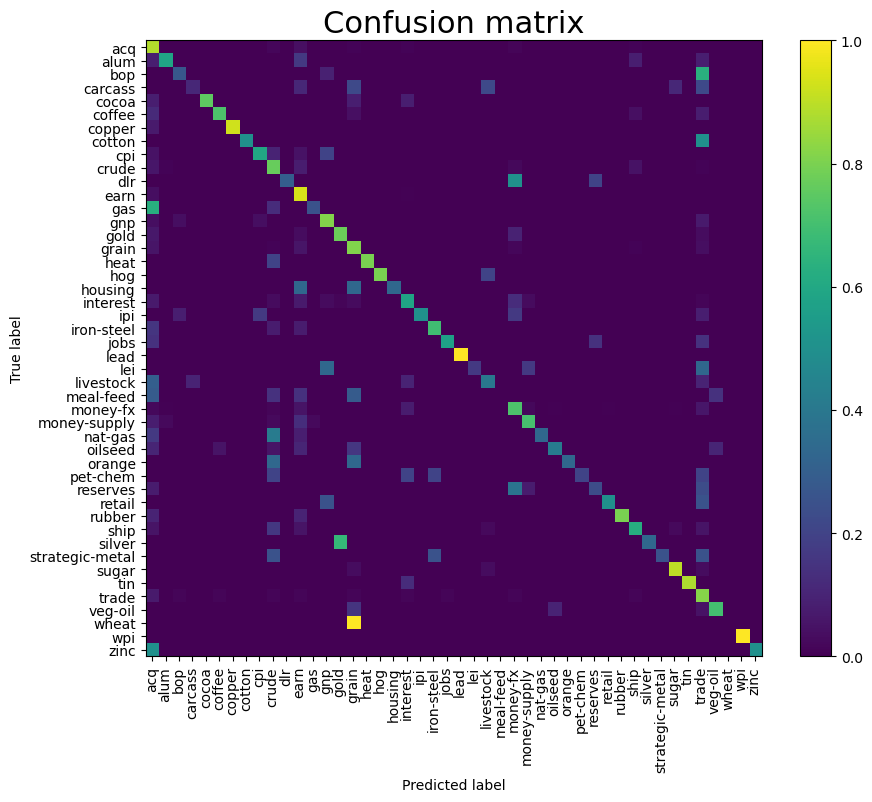

In [47]:
# Plot a confusion matrix
_, ax = plt.subplots(figsize=(10,8))
ConfusionMatrixDisplay.from_predictions(true_class, predicted_class, 
                                        xticks_rotation='vertical', 
                                        normalize='true', include_values=False, ax=ax)

ax.set_title('Confusion matrix', fontsize=22)
plt.show()

> **Key Insights**
>
> The model has difficulty learning the smaller classes effectively. Several strategies can be considered: merging the smallest classes into more coherent classes (e.g. `grain` and `wheat`), or using oversampling techniques like SMOTE to synthetically generate additional data.

## Conclusion

In this report, we adhered to best practices in designing and refining a neural network for multi-class classification using Keras. Beginning with a common-sense baseline, we progressively developed more sophisticated models, carefully balancing complexity and generalisation. 

The evaluation demonstrated strong performance for dominant classes but highlighted significant challenges with rare and underrepresented categories due to class imbalance. Misclassifications were particularly noticeable for minority classes and semantically similar categories, such as `carcass` and `meal-feed`, reflecting the difficulty in distinguishing overlapping patterns. These insights emphasise the importance of strategies such as class weighting, oversampling, and advanced loss functions to enhance generalisation across all classes. Future work could explore dense word embeddings like GloVe or contextual embeddings such as BERT to capture richer semantic relationships.

Throughout this coursework, we followed the universal workflow of machine learning, performing a systematic and structured examination of the process. Starting with simple models and incrementally increasing their complexity, we explored the trade-offs between model capacity and generalisation. While improvements eventually plateaued, this investigation provided valuable experience in experimenting with various configurations and demonstrated how Keras’ modular and intuitive design lets data scientists tackle complex classification challenges, combining scientific precision with creative problem-solving.

## Bibliography and References

- Alpaydin, E. (2014) *Introduction to machine learning*. 3rd edn. Cambridge, MA: MIT Press.
- Bruce, P.C. and Bruce, A. (2020) *Practical statistics for data scientists: 50 essential concepts*. 1st edn. Sebastopol, CA: O'Reilly Media.
- Chollet, F. (2018). *Deep Learning with Python*. Manning Publications.
- Chollet, F. (2022). *Deep Learning with Python* (2nd ed.). Manning Publications.
- Chollet, F. (2024). *Deep Learning with Python* (3rd ed., MEAP). Manning Publications.
- Grus, J. (2015). *Data science from scratch: First principles with Python.* O'Reilly Media.
- McKinney, W. (2014). *Python for data analysis*, First Edition, Third release. ed. O’Reilly, Beijing.
- Murphy, K.P. (2012) *Machine learning: A probabilistic perspective*. Cambridge, MA: MIT Press.
- Karpathy, A. (2019) *A recipe for training neural networks*. Available at: [https://karpathy.github.io/2019/04/25/recipe/](https://karpathy.github.io/2019/04/25/recipe/) (Accessed: 26 December 2024). 
- Smith, L.N. (2018). *A disciplined approach to neural network hyper-parameters: Part 1 -- learning rate, batch size, momentum, and weight decay.* https://doi.org/10.48550/arXiv.1803.09820
